### Loading ad preping the data

In [187]:
import pandas as pd
import numpy as np

summary_df = pd.read_csv("summary.csv")
static_df = pd.read_csv("static.csv")
df = summary_df.merge(static_df, on = "RunID", how = "inner")
feature_cols = [
        # "max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        # "max_ram_used_mb",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]
assert len(df) == len(summary_df), "Different number of entries"
# print(df.head())
print(static_df["game_name"].value_counts(normalize=True))
print(static_df["training_type"].value_counts(normalize=True))

game_name
3DBall               0.460666
3DBallHard           0.339121
Crawler              0.071580
GridFoodCollector    0.057229
PushBlock            0.029943
Hallway              0.021262
Pyramids             0.004429
Walker               0.004429
Worm                 0.004429
Sorter               0.003898
GridWorld            0.003012
Name: proportion, dtype: float64
training_type
ppo    0.980865
sac    0.019135
Name: proportion, dtype: float64


In [216]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

def get_subsample_mask(sanitized_df : pd.DataFrame, instances_per_machine_game_pair = 5):
    subsampled = sanitized_df.groupby(["cpu", "game_name", "training_type"], group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), instances_per_machine_game_pair),
            random_state=42
        )
    )
    used_run_ids = set(subsampled["RunID"])
    return sanitized_df["RunID"].isin(used_run_ids)

X = create_feature_data_frame(df)
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()
subsample_mask = get_subsample_mask(df_sanitized)

X_sanitized = X_sanitized[subsample_mask]
df_sanitized = df_sanitized[subsample_mask]

def get_sanitized_and_subsampled_features_and_org_df(df : pd.DataFrame, subsample = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    if subsample:
        subsample_mask = get_subsample_mask(df_sanitized, instances_per_machine_game_pair=5)
        X_sanitized = X_sanitized[subsample_mask].copy()
        df_sanitized = df_sanitized[subsample_mask].copy()
    return X_sanitized, df_sanitized

print(f"Number of significantly long runs (time_per_1000_stpes_sec > 10) : {len(X[X["time_per_1000_steps_sec"]>10])}")
print(f"Number of deleted entries : {len(X) - len(X_sanitized)}")
print(f"Number of entires remainig : {len(X_sanitized)}")

Number of significantly long runs (time_per_1000_stpes_sec > 10) : 83
Number of deleted entries : 5362
Number of entires remainig : 282


In [175]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_68646/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,15.000000,15.000000,15.000000
mean,23.265266,8197.712306,10.409248
std,5.585442,7196.852216,10.116320
min,16.166667,2904.025830,2.918337
25%,18.869939,2965.551459,4.159030
50%,22.218167,3591.258325,6.029525
75%,26.581125,17751.552675,11.825956
max,33.568833,18245.840000,39.201016


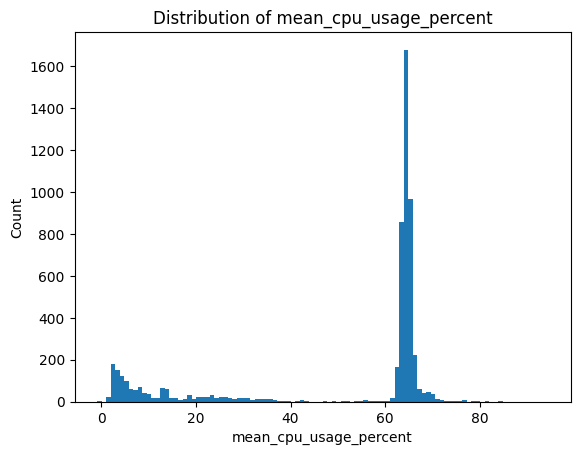

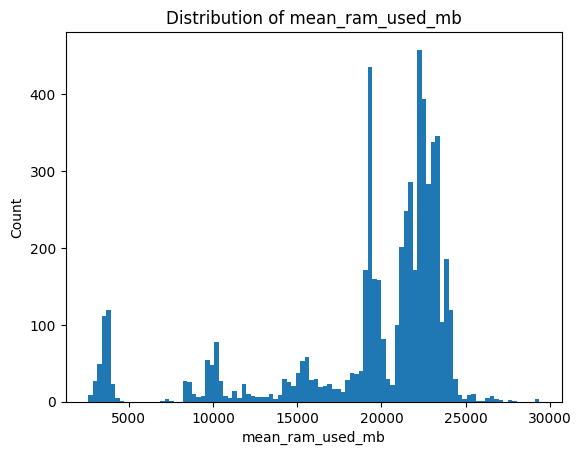

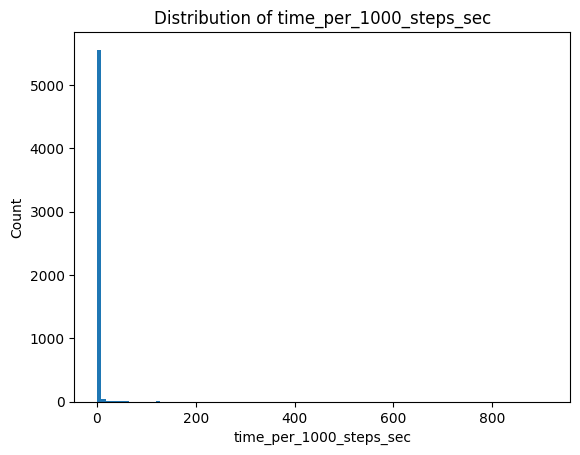

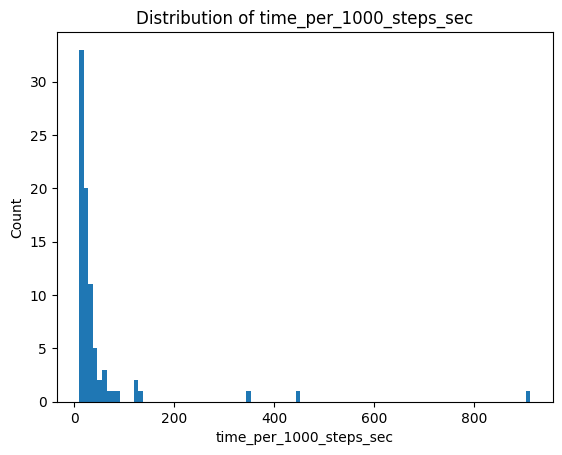

In [ ]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    ax = plt.axes()
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    ax.set_xscale("log")
    plt.show()
    
plot_distribuiton_of_features()


In [177]:
print(static_df.cpu.unique())
print(len(static_df[static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor"]))
# test = static_df[static_df["cpu"] == "Apple M1"]
# print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor") & (static_df["training_type"] == "sac")]
print(test["training_type"].value_counts())
print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "Apple M1") & (static_df["training_type"] == "sac")]
print(len(test))

['AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD' 'Apple M2'
 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD'
 'AMD Ryzen 7 9800X3D 8-Core Processor'
 'AMD Ryzen 7 5700X 8-Core Processor' 'Apple M1']
4144
training_type
sac    8
Name: count, dtype: int64
game_name
Crawler              1
GridFoodCollector    1
Hallway              1
PushBlock            1
Pyramids             1
Sorter               1
Walker               1
Worm                 1
Name: count, dtype: int64
38


In [148]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_log = X_sanitized.copy()
    X_log["time_per_1000_steps_sec"] = np.log1p(X_log["time_per_1000_steps_sec"])
    X_log["mean_ram_used_mb"] = np.log1p(X_log["mean_ram_used_mb"])
    X_scaled_as_array = scaler.fit_transform(X_log)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

def cluster(X_scaled_as_array : np.ndarray, n_init = "auto", n_clusters = 5) -> tuple[np.ndarray, KMeans]:
    clf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init, init="k-means++")
    clusters = clf.fit_predict(X_scaled_as_array)    
    return clusters, clf
    
def cluster_and_show(n_init = "auto", n_clusters = 5) -> None:
    X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
    X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
    X_scaled.describe()

    X_scaled["clusters"] = cluster(X_scaled_as_array, n_init=n_init, n_clusters = n_clusters)[0]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = X_scaled["clusters"])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
def show_clustered(X_scaled) -> None:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    clusters = X_scaled["cluster"].unique()

    for cluster in clusters:
        mask = X_scaled["cluster"] == cluster
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f"Cluster {cluster}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Clusters")
    plt.show()

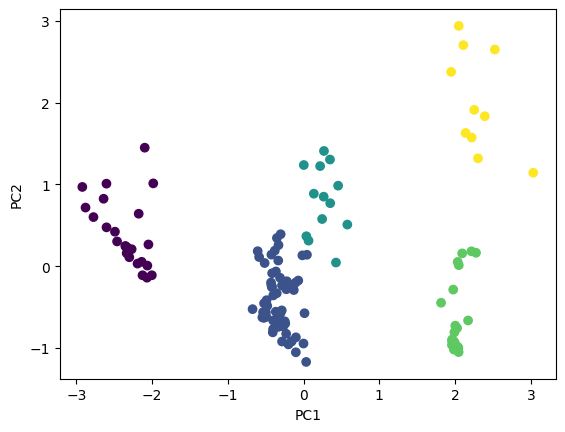

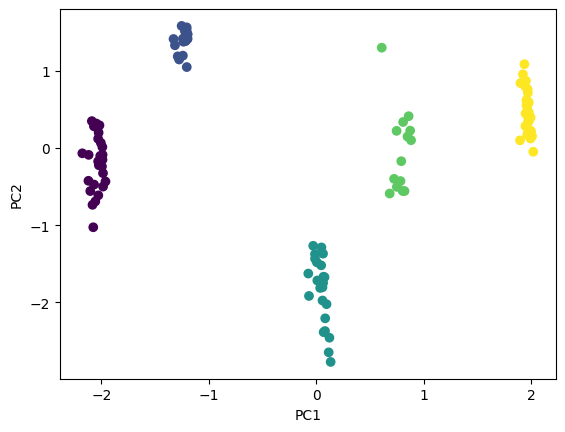

In [86]:
cluster_and_show(n_init="auto")
cluster_and_show(n_init=10)



In [ ]:
import numpy as np
pca = PCA(n_components=2)
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
X_pca_1 = pca.fit_transform(X_scaled)
X_pca_2 = pca.fit_transform(X_scaled)

np.allclose(X_pca_1, X_pca_2)

labels_auto = KMeans(n_clusters=5, n_init="auto", random_state=42).fit_predict(X_scaled)
labels_10 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

(labels_auto == labels_10).mean()


0.0

In [88]:
clusters, clf = cluster(X_scaled_as_array)
X_sanitized["cluster"] = clf.labels_
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# print(cluster_summary)
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = X_sanitized["cluster"]
# static_cluster_3 = df_sanitized.loc[X_sanitized["cluster"] == 3]
# print(static_cluster_3)
# static_cluster_3.head()
# X_sanitized[X_sanitized["cluster"] == 3]["RunID"]
# X_sanitized
# print(summary_df_sanitized[X_sanitized["cluster"] == 3])
# df_sanitized[X_sanitized["cluster"] == 3]
# df_sanitized_with_clusters.head()
print(df_sanitized_with_clusters.columns)
print(X_sanitized["cluster"].value_counts())

Index(['RunID', 'final_reward', 'max_reward', 'time_to_max_reward_sec',
       'total_duration_sec', 'mean_policy_loss', 'mean_value_loss',
       'mean_entropy', 'final_entropy', 'max_cpu_usage_percent',
       'mean_cpu_usage_percent', 'max_ram_used_mb', 'mean_ram_used_mb',
       'mean_cpu_frequency', 'max_cpu_frequency', 'max_gpu_usage_percent',
       'mean_gpu_usage_percent', 'max_vram_used_mb', 'mean_vram_used_mb',
       'max_game_cpu_usage_percent', 'mean_game_cpu_usage_percent',
       'max_game_memory_usage_mb', 'mean_game_memory_usage_mb', 'os', 'cpu',
       'physical_cores', 'system_ram_gb', 'gpu', 'GPU_ram_mb', 'cuda_version',
       'training_type', 'game_name', 'batch_size', 'learning_rate',
       'buffer_size', 'beta', 'epsilon', 'lambd', 'num_epoch',
       'learning_rate_schedule', 'normalize', 'hidden_units', 'num_layers',
       'vis_encode_type', 'reward_extrinsic_gamma',
       'reward_extrinsic_strength', 'keep_checkpoints', 'max_steps',
       'time_horizon',

In [89]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"])

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,4,2,2,0,2,3,1,3,2,2,3
1,7,4,8,4,1,6,7,6,4,6,6
2,2,2,2,3,1,1,1,0,0,1,0
3,4,2,3,3,0,3,2,2,1,2,2
4,1,0,0,3,2,0,0,0,4,0,0


In [90]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
cluster,,
0,21,3
1,39,20
2,2,11
3,17,7
4,2,8


In [91]:
pd.crosstab(df_sanitized_with_clusters["game_name"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
game_name,,
3DBall,12,6
3DBallHard,6,4
Crawler,8,7
GridFoodCollector,8,5
GridWorld,4,2
Hallway,8,5
PushBlock,7,4
Pyramids,7,4
Sorter,7,4


In [92]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["cpu"])

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,22,0,2,0,0,0
1,1,0,0,0,32,26
2,13,0,0,0,0,0
3,0,22,0,2,0,0
4,3,1,0,0,3,3


In [94]:
display(cluster_summary)
display(df_sanitized_with_clusters)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                     5.061000   1.724360   1.952846   7.838760   
1                    25.705459   5.588656  16.153333  42.872490   
2                    15.976533   3.466175  10.859780  22.822000   
3                    63.740887   6.015632  49.398394  73.460501   
4                    24.785887  11.949661  13.427500  55.329807   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
0           12364.143247  3248.067099   8629.987952  21387.705426   
1            3553.799694  1451.912550   2588.723328  14274.500000   
2           13257.333983  2896.446189   9059.728125  18245.840000   
3           20727.254722  2142.370281  18424.992647  24726.250000   
4            8145.898220  6775.594606   2823.696663  19176.105469   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
0                      3.143413    6.946035   0.494379   32.105184  
1                      4.973604    5.713067   0.412098   25.862674  
2                     18.226198   14.424281   2.624320   46.317793  
3                      4.191394    6.922112   0.296986   23.334980  
4                    233.013256  274.483574  39.201016  912.552125

,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq,time_per_1000_steps_sec,cluster
81,20251123-104448,1.660690,1.725176,129.753540,152.015106,0.024820,0.082402,1.410354,1.398661,6.166667,...,3,simple,NaN,NaN,5,250000,2048,12000,0.608060,0
144,20251123-155213,92.330788,100.000015,251.571182,1287.505249,0.034564,0.011228,1.372261,1.352698,22.450001,...,3,simple,NaN,NaN,5,2000000,128,12000,0.643753,1
162,20251123-113435,3.954238,4.716506,1223.479248,1543.667969,0.017149,0.647729,1.374840,1.345095,39.433334,...,1,simple,NaN,NaN,5,2000000,1024,12000,0.771834,1
192,20251123-201630,1.986375,1.986375,80.380363,80.380363,0.025602,0.155376,1.416580,1.410529,8.150000,...,2,simple,NaN,NaN,5,100000,2048,12000,0.803804,0
214,20251125-150540,1.272475,1.303000,128.876526,142.151413,0.012250,0.204714,1.405853,1.391715,4.966667,...,1,simple,NaN,NaN,5,250000,256,12000,0.568606,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,20251221-033804,0.176471,0.750000,1744.052490,1934.677612,0.011675,0.002557,2.112354,2.112579,23.900000,...,3,simple,NaN,NaN,5,500000,512,12000,3.869355,1
5639,20251221-042400,0.409266,0.446033,2627.455322,3328.799072,0.034694,0.027798,0.712965,0.154849,30.200001,...,3,simple,NaN,NaN,5,2000000,256,12000,1.664400,1
5640,20251228-012106,-1.039356,-0.729547,16647.429688,122156.382812,-2.193208,0.000698,1.031312,0.818584,36.599998,...,1,simple,NaN,NaN,5,1000000,256,10000,122.156383,4
5642,20251221-193027,0.049431,0.710895,259.797821,309.197815,0.035861,0.047049,1.420335,1.420728,42.933334,...,1,simple,NaN,NaN,5,250000,256,12000,1.236791,1


In [67]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

Q1 = X_sanitized.quantile(0.25)
Q3 = X_sanitized.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_sanitized < (Q1 - 1.5 * IQR)) | (X_sanitized > (Q3 + 1.5 * IQR))
outlier_rows = outlier_mask.any(axis=1)
len(outlier_rows == False)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)

In [95]:
from sklearn.metrics import silhouette_score
# For finding proper k
k_range = range(2, 20)

inertias = []
silhouette_scores = []


for k in k_range:
    # kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X_scaled_as_array)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
    
results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

print(results)

     k     inertia  silhouette_score
0    2  150.249185          0.478252
1    3   90.951692          0.510570
2    4   53.744318          0.535860
3    5   45.323422          0.521433
4    6   36.456963          0.483770
5    7   32.989292          0.449518
6    8   25.377377          0.471568
7    9   22.105411          0.459145
8   10   18.918186          0.473850
9   11   17.674061          0.460721
10  12   14.674655          0.484512
11  13   13.741633          0.478003
12  14   11.939942          0.471351
13  15   11.032124          0.468993
14  16   10.369853          0.448439
15  17    9.001919          0.439241
16  18    8.408581          0.426428
17  19    7.973818          0.408402


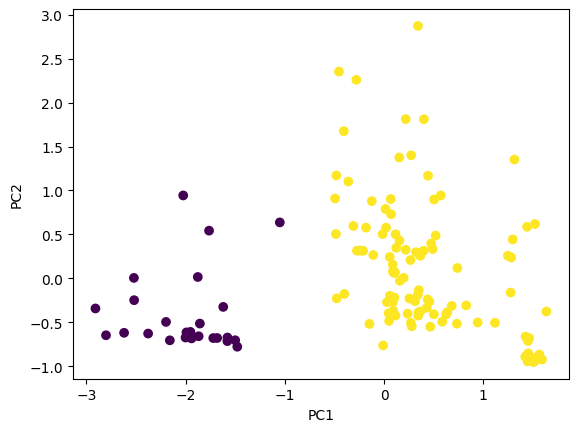

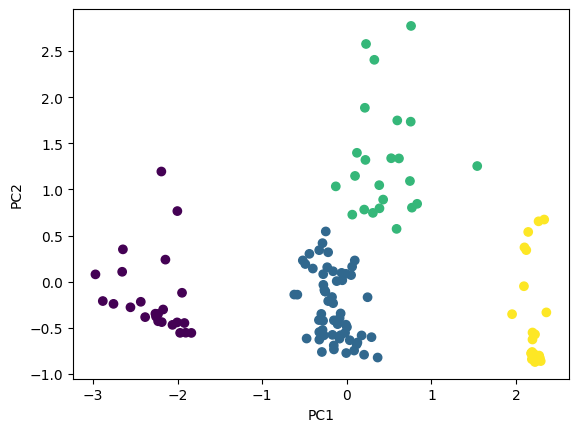

In [96]:
cluster_and_show(n_clusters=2)
cluster_and_show(n_clusters=4)

In [75]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=5, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
display(cluster_summary)
pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"]))


mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                    19.397581   9.878652   1.952846  42.872490   
1                    24.949333        NaN  24.949333  24.949333   
2                    14.457917   1.457229  13.427500  15.488333   
3                    63.740887   6.015632  49.398394  73.460501   
4                    29.853551  17.790717  14.170000  55.329807   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
0            6951.238291  4959.622342   2588.723328  21387.705426   
1            3093.520010          NaN   3093.520010   3093.520010   
2           14264.570630  4899.312835  10800.233301  17728.907959   
3           20727.254722  2142.370281  18424.992647  24726.250000   
4           10105.672937  8123.276095   2823.696663  19176.105469   

        time_per_1000_steps_sec                                     
                           mean        std         min         max  
cluster                                                             
0                      7.638387  11.719503    0.412098   57.159785  
1                    912.552125        NaN  912.552125  912.552125  
2                    399.798652  72.003606  348.884414  450.712891  
3                      4.191394   6.922112    0.296986   23.334980  
4                    116.901984  18.468286   90.034521  132.191891

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,14,8,12,8,5,10,9,9,6,9,9
1,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,1,0,0
3,4,2,3,3,0,3,2,2,1,2,2
4,0,0,0,2,0,0,0,0,2,0,0


training_type,ppo,sac
cluster,,
0,63,36
1,0,1
2,0,2
3,17,7
4,1,3


In [76]:
X_sanitized.corr()
X_sanitized["cluster"].value_counts()

cluster
0    99
3    24
4     4
2     2
1     1
Name: count, dtype: int64

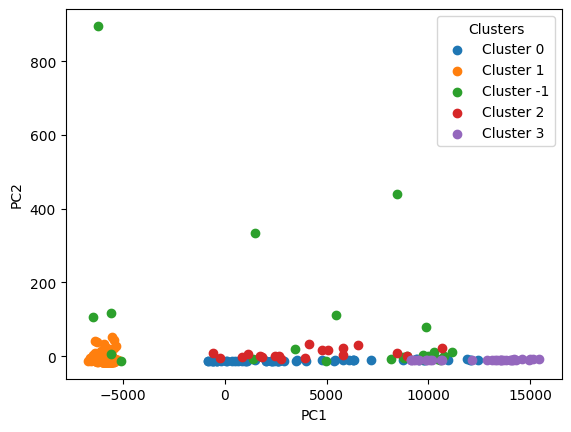

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   36.529888  20.672755   4.636000  73.460501   
 0                    6.064332   3.277430   1.737500  14.785976   
 1                   26.762510   6.090325  16.153333  45.424243   
 2                   14.774871   3.519107   5.927114  22.822000   
 3                   65.331050   3.198255  56.639431  71.812450   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          14626.424451  6290.582936   2823.696663  20464.625000   
 0          13395.251156  4179.939478   8451.416748  21702.772358   
 1           3392.356724   312.983623   2588.723328   4047.323743   
 2          13333.295610  3124.149567   8734.066699  19947.100000   
 3          21714.412660  2156.818618  18424.992647  24726.250000   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                    94.508912  203.439591  0.412098  912.552125  
 0                     1.195750    0.906296  0.471672    4.165636  
 1                     8.118052   12.593481  0.627457   69.295352  
 2                    20.623944   11.692512  5.403695   46.317793  
 3                     0.623826    0.425462  0.230291    1.826646

cluster
 1    146
 0     59
 3     33
-1     25
 2     19
Name: count, dtype: int64

In [223]:
from sklearn.cluster import DBSCAN
X_sanitized_dbscan, df_sanitized_dbscan = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled_dbscan, X_scaled_as_array_dbscan = get_scaled_df_and_np(X_sanitized_dbscan)

dbscan = DBSCAN(eps = 0.4, min_samples = 5)
labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
X_sanitized_dbscan["cluster"] = labels
df_sanitized_dbscan["cluster"] = labels
show_clustered(X_sanitized_dbscan)

cluster_dbscan_summary = (
    X_sanitized_dbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_dbscan_summary)
X_sanitized_dbscan["cluster"].value_counts()

In [195]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["game_name"]))

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,3,9,0,1,2,2
0,155,0,15,0,0,0
1,0,0,0,0,81,115
2,0,79,0,14,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,1,0,1,3,1,3,1,2,4,1,0
0,45,21,21,18,14,8,16,7,6,7,7
1,31,21,31,21,2,16,16,15,11,16,16
2,29,15,15,15,0,13,1,1,1,1,2


In [225]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan[df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor"]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["os"]))
display(pd.crosstab(df_sanitized_dbscan["cpu"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab( df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,4,0,0,1,1,1,1,0,2,0,0
0,5,5,5,5,5,5,4,6,4,5,5
2,1,5,5,3,1,1,1,0,0,1,1


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cluster,,,,,
-1,5,5,2,3,10
0,42,17,0,0,0
1,0,0,81,65,0
2,18,1,0,0,0
3,0,0,0,0,33


os,Windows 11,macOS
cluster,,
-1,20,5
0,59,0
1,0,146
2,19,0
3,33,0


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cpu,,,,,
AMD Ryzen 7 5700X 8-Core Processor,65,18,0,0,0
AMD Ryzen 7 9800X3D 8-Core Processor,0,0,0,0,38
"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",0,5,0,0,0
"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",0,0,0,0,5
Apple M1,0,0,83,0,0
Apple M2,0,0,0,68,0


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,10,8,0,2,2,3
0,54,0,5,0,0,0
1,0,0,0,0,81,65
2,19,0,0,0,0,0
3,0,30,0,3,0,0


In [220]:
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "Apple M2")]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor")]["game_name"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,2,5,5,5,5,5,5
sac,5,5,5,1,0,0,0,0,0,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,5,5,5,5,5,5,5
sac,5,5,5,4,2,2,1,1,1,1,1


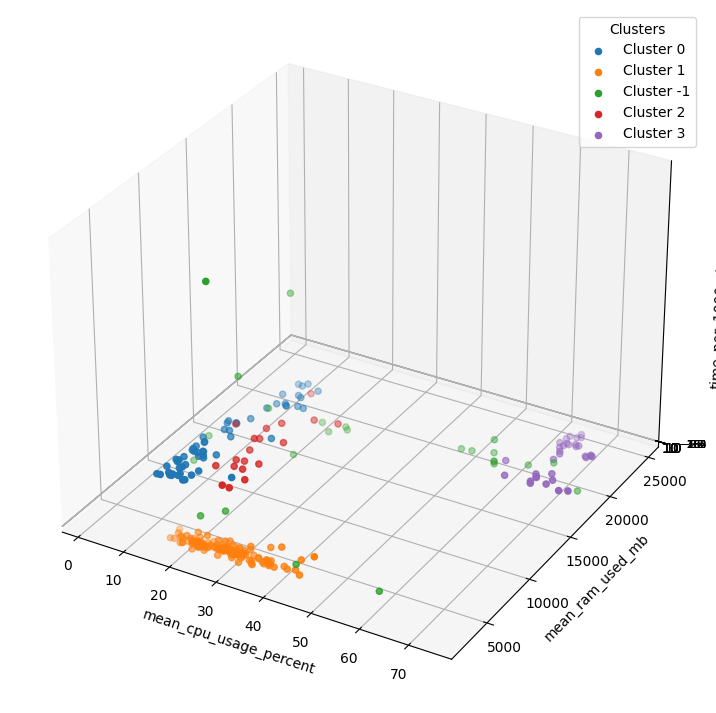

In [222]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

def show_clustered_3d_log(X_scaled) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    clusters = X_scaled["cluster"].unique()

    for cluster in clusters:
        mask = X_scaled["cluster"] == cluster
        ax.scatter(
            X_scaled.loc[mask, "mean_cpu_usage_percent"],
            X_scaled.loc[mask, "mean_ram_used_mb"],
            X_scaled.loc[mask, "time_per_1000_steps_sec"],
            label=f"Cluster {cluster}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="Clusters")
    plt.show()

show_clustered_3d_log(X_sanitized_dbscan)

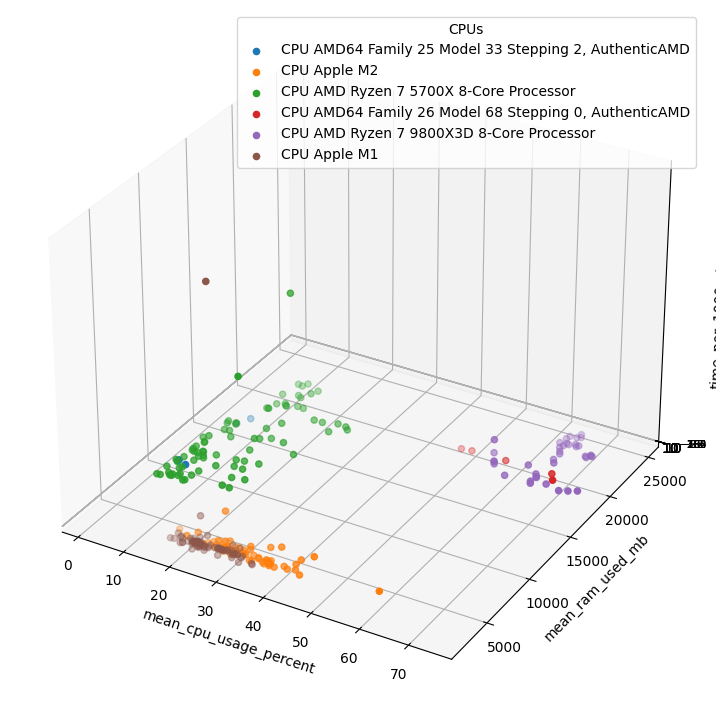

In [219]:
def show_by_cpu_3d_log(X_scaled) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    cpus = X_scaled["cpu"].unique()

    for cpu in cpus:
        mask = X_scaled["cpu"] == cpu
        ax.scatter(
            X_scaled.loc[mask, "mean_cpu_usage_percent"],
            X_scaled.loc[mask, "mean_ram_used_mb"],
            X_scaled.loc[mask, "time_per_1000_steps_sec"],
            label=f"CPU {cpu}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="CPUs")
    plt.show()

show_by_cpu_3d_log(df_sanitized_dbscan)

In [215]:
display(static_df[["cpu", "system_ram_gb"]].drop_duplicates())
display(static_df[["gpu", "system_ram_gb"]].drop_duplicates())

,cpu,system_ram_gb
0,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",34265653248
153,Apple M2,8589934592
203,"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",66157809664
253,AMD Ryzen 7 9800X3D 8-Core Processor,66157809664
510,AMD Ryzen 7 5700X 8-Core Processor,34265653248
5561,Apple M1,8589934592


,gpu,system_ram_gb
0,NVIDIA GeForce RTX 5080,34265653248
153,Chipset Model: Apple M2,8589934592
203,NVIDIA GeForce RTX 5070 Ti,66157809664
5561,Chipset Model: Apple M1,8589934592
